In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.57 s (started: 2026-06-29 18:28:09 +02:00)


In [2]:
scarf.fetch_dataset("tenx_8K_pbmc_citeseq", save_path="scarf_datasets")

time: 27 s (started: 2026-06-29 18:28:11 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_8K_pbmc_citeseq/data.h5")

time: 65.6 ms (started: 2026-06-29 18:28:38 +02:00)


In [4]:
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 11.5 ms (started: 2026-06-29 18:28:38 +02:00)


In [5]:
reader.rename_assays({"assay2": "ADT"})
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 4.86 ms (started: 2026-06-29 18:28:38 +02:00)


In [6]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

  0%|                                                                                                         …

time: 13 s (started: 2026-06-29 18:28:38 +02:00)


In [7]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr", default_assay="RNA", nthreads=4
)

(ADT) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(ADT) Computing nCounts:   0%|                                                                                …

(ADT) Computing nFeatures:   0%|                                                                              …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 8.53 s (started: 2026-06-29 18:28:51 +02:00)


In [8]:
ds

DataStore has 7865 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'ADT_nCounts', 
            'RNA_percentRibo', 'RNA_nFeatures', 'ADT_nFeatures', 'RNA_nCounts'
   RNA assay has 13832 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   ADT assay has 17 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 82.1 ms (started: 2026-06-29 18:29:00 +02:00)


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,7865
1,False,ENSG00000237613,FAM138A,0,7865
2,False,ENSG00000186092,OR4F5,0,7865
3,False,ENSG00000238009,AL627309.1,12,7853
4,False,ENSG00000239945,AL627309.3,0,7865


time: 65.4 ms (started: 2026-06-29 18:29:00 +02:00)


In [10]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


time: 61.5 ms (started: 2026-06-29 18:29:00 +02:00)


INFO: 154 cells flagged for filtering out using attribute RNA_nCounts


INFO: 326 cells flagged for filtering out using attribute RNA_nFeatures


INFO: 119 cells flagged for filtering out using attribute RNA_percentMito


INFO: 21 cells flagged for filtering out using attribute RNA_percentRibo


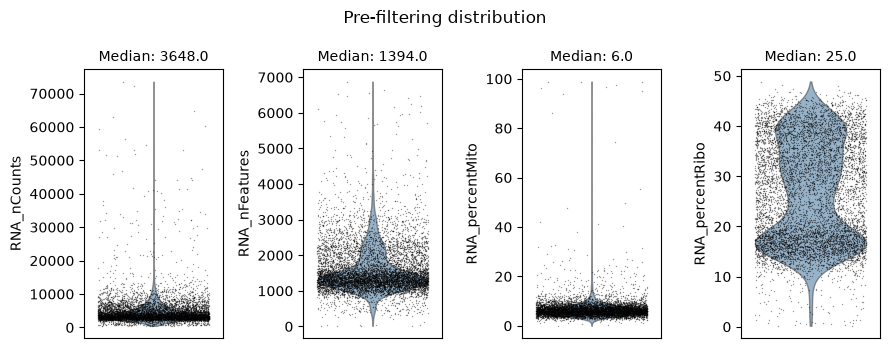

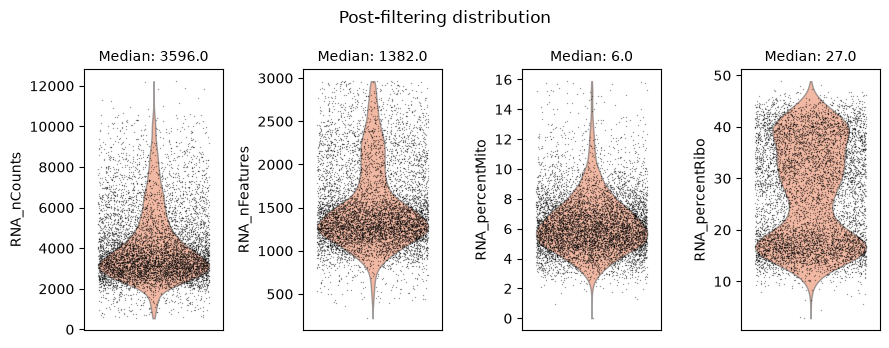

time: 2.56 s (started: 2026-06-29 18:29:00 +02:00)


In [11]:
ds.auto_filter_cells()

INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 997 genes marked as HVGs


/home/parashar/scarf/scarf/plots.py:394: RuntimeWarning: divide by zero encountered in log2
  nzm = np.log2(nzm)
/home/parashar/scarf/scarf/plots.py:395: RuntimeWarning: divide by zero encountered in log2
  fv = np.log2(fv)


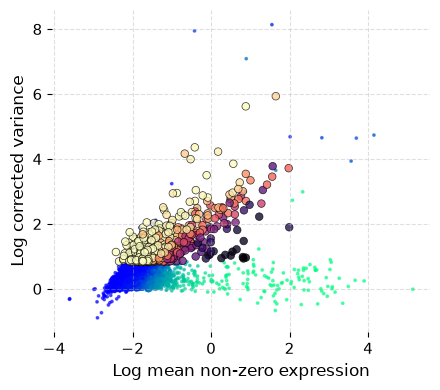

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 3.3s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 16.2s (7/7 steps, 16.1s in logged steps)


Training UMAP:   0%|                                                                                          …

time: 34.1 s (started: 2026-06-29 18:29:02 +02:00)


In [12]:
ds.mark_hvgs(min_cells=20, top_n=1000, min_mean=-3, max_mean=2, max_var=6)

ds.make_graph(feat_key="hvgs", k=21, dims=15, n_centroids=100)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(resolution=1)

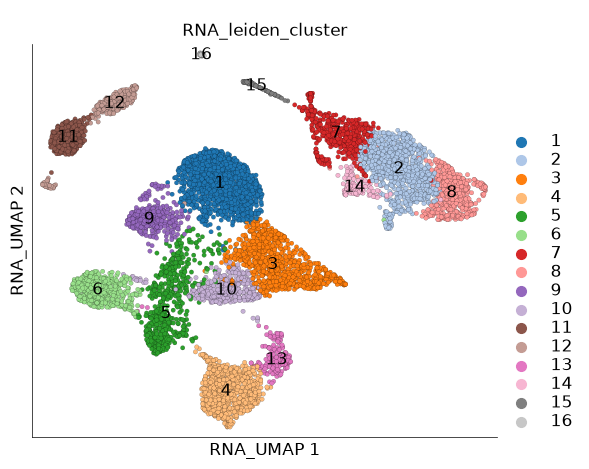

time: 563 ms (started: 2026-06-29 18:29:36 +02:00)


In [13]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_leiden_cluster", cmap="tab20")

In [14]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 39.7 ms (started: 2026-06-29 18:29:37 +02:00)


In [15]:
adt_names = ds.ADT.feats.to_pandas_dataframe(["names"])["names"]
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

time: 16.7 ms (started: 2026-06-29 18:29:37 +02:00)


In [16]:
is_control = adt_names.str.contains("control").values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

time: 2.67 ms (started: 2026-06-29 18:29:37 +02:00)


In [17]:
ds.ADT.feats.update_key(~is_control, "I")
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 50.1 ms (started: 2026-06-29 18:29:37 +02:00)


In [18]:
print(ds.ADT)
print(ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr
time: 6.07 ms (started: 2026-06-29 18:29:37 +02:00)


In [19]:
ds.make_graph(from_assay="ADT", feat_key="I", k=21, dims=0, n_centroids=100)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__I/data:   0%|                                                                      …

INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: ANN recall: 99.99%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 0.6s (7/7 steps, 0.6s in logged steps)


time: 653 ms (started: 2026-06-29 18:29:37 +02:00)


In [20]:
ds.run_umap(from_assay="ADT", n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(from_assay="ADT", resolution=1)

Training UMAP:   0%|                                                                                          …

time: 4.14 s (started: 2026-06-29 18:29:38 +02:00)


In [21]:
ds.cells.head()

,I,ids,names,RNA_percentRibo,RNA_leiden_cluster,RNA_nFeatures,ADT_UMAP2,RNA_percentMito,ADT_UMAP1,RNA_UMAP2,RNA_UMAP1,ADT_leiden_cluster,RNA_nCounts,ADT_nCounts,ADT_nFeatures
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,15.259740,8,2194.0,-8.658511,8.668831,-32.909435,9.241634,34.282509,5,6160.0,981.0,17.0
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,19.037688,8,2093.0,-14.780369,6.316103,-20.838619,7.864933,33.022591,13,6713.0,1475.0,17.0
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,16.002200,2,1518.0,-16.245176,8.056090,-26.864435,12.296372,20.581911,5,3637.0,7149.0,17.0
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,18.729904,4,737.0,-27.613340,9.003215,23.853218,-30.166466,-3.040479,3,1244.0,6831.0,17.0
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,16.353887,4,1240.0,-25.332369,6.204519,24.874107,-34.625256,0.506812,3,2611.0,6839.0,17.0


time: 193 ms (started: 2026-06-29 18:29:42 +02:00)


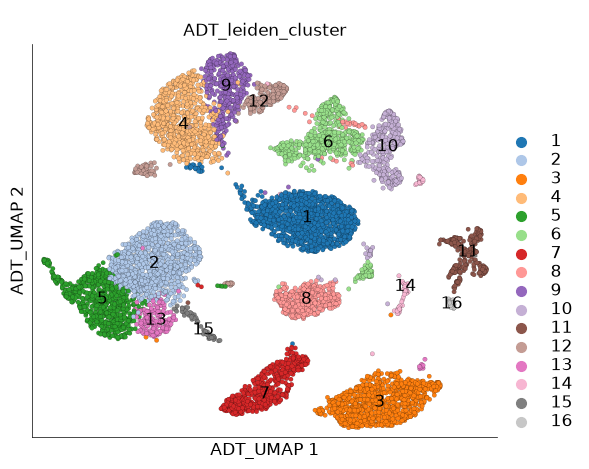

time: 475 ms (started: 2026-06-29 18:29:42 +02:00)


In [22]:
ds.plot_layout(layout_key="ADT_UMAP", color_by="ADT_leiden_cluster", cmap="tab20")

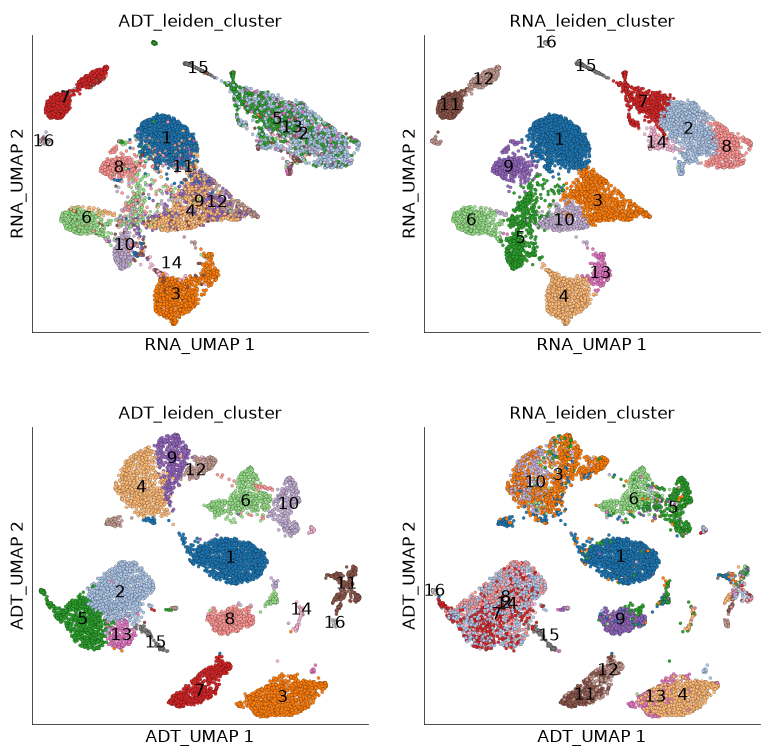

time: 1.12 s (started: 2026-06-29 18:29:43 +02:00)


In [23]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by=["ADT_leiden_cluster", "RNA_leiden_cluster"],
    cmap="tab20",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
    legend_onside=False,
)

In [24]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"), ds.cells.fetch("ADT_leiden_cluster")
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
row_0,,,,,,,,,,,,,,,,
1,1039,0,0,43,3,17,0,33,29,1,17,57,0,0,0,0
2,0,447,1,5,266,15,2,0,4,4,52,2,78,20,0,0
3,23,0,0,366,1,9,0,4,267,15,20,154,0,0,0,0
4,0,0,724,0,0,0,0,0,0,0,29,0,0,37,0,0
5,21,0,2,4,0,100,0,55,43,299,29,3,0,8,0,0
6,0,0,1,25,0,403,0,6,1,2,14,0,0,1,0,0
7,0,172,2,0,219,1,0,0,1,0,13,0,34,6,5,0
8,0,304,0,0,91,0,0,0,1,0,12,0,41,2,0,0
9,10,1,0,0,4,17,0,342,0,4,6,4,0,0,0,0


time: 117 ms (started: 2026-06-29 18:29:44 +02:00)


In [25]:
(100 * df.max() / df.sum()).sort_values(ascending=False)

col_0
16    100.000000
1      94.972578
10     89.253731
15     86.956522
3      82.554162
8      76.339286
9      70.448549
6      69.482759
12     66.379310
7      60.611855
4      51.476793
13     48.750000
14     46.835443
2      45.015106
5      41.758242
11     20.634921
dtype: float64

time: 5.41 ms (started: 2026-06-29 18:29:44 +02:00)


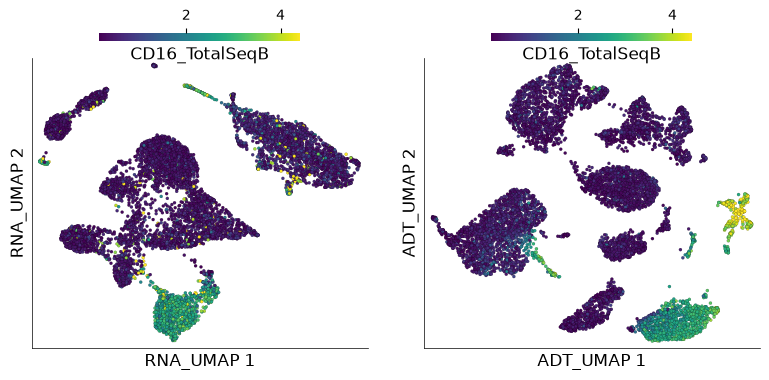

time: 1 s (started: 2026-06-29 18:29:44 +02:00)


In [26]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="CD16_TotalSeqB",
    from_assay="ADT",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

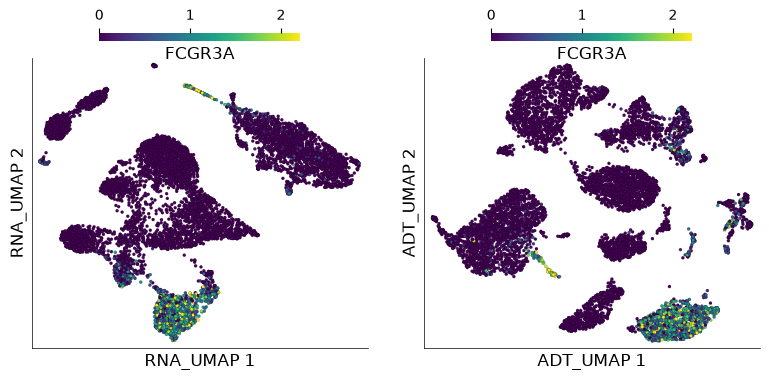

time: 1.23 s (started: 2026-06-29 18:29:45 +02:00)


In [27]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="FCGR3A",
    from_assay="RNA",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

In [28]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT")

Identifying SNNs in graphs:   0%|                                                                             …

Merging graph edges:   0%|                                                                                    …

time: 2.99 s (started: 2026-06-29 18:29:46 +02:00)


In [29]:
ds.run_umap(
    integrated_graph="RNA+ADT", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT", resolution=1.75)

Training UMAP:   0%|                                                                                          …

time: 8.45 s (started: 2026-06-29 18:29:49 +02:00)


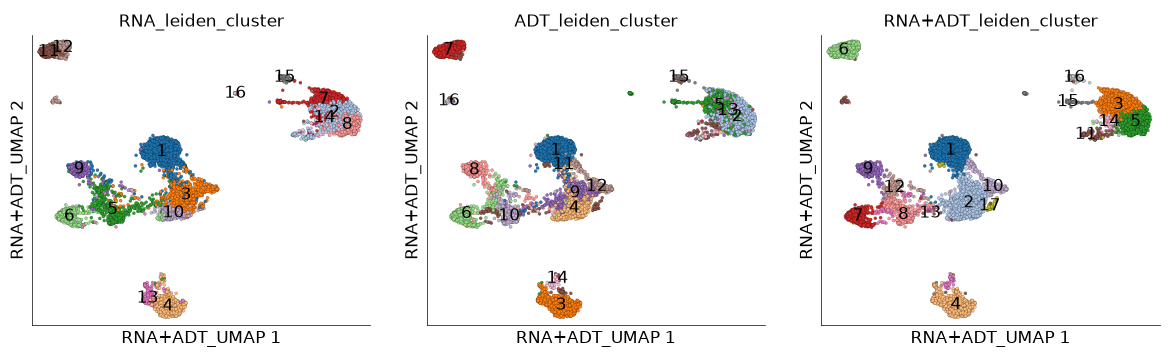

time: 630 ms (started: 2026-06-29 18:29:58 +02:00)


In [30]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP"],
    color_by=["RNA_leiden_cluster", "ADT_leiden_cluster", "RNA+ADT_leiden_cluster"],
    cmap="tab20",
    legend_onside=False,
    point_size=5,
    width=4,
    height=4,
    n_columns=3,
)

In [31]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA+ADT_UMAP2',
 'RNA_UMAP1',
 'ADT_leiden_cluster',
 'RNA_UMAP2',
 'RNA+ADT_UMAP1',
 'ADT_UMAP1',
 'ADT_UMAP2',
 'RNA+ADT_leiden_cluster',
 'RNA_leiden_cluster',
 'ADT_nFeatures',
 'RNA_nFeatures',
 'RNA_nCounts',
 'RNA_percentRibo',
 'ADT_nCounts',
 'RNA_percentMito']

time: 11.6 ms (started: 2026-06-29 18:29:58 +02:00)


In [32]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT_wnn", method="wnn")

ds.run_umap(
    integrated_graph="RNA+ADT_wnn", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT_wnn", resolution=1.75)

INFO: make_graph step 1/7: normalize expression matrix (reusing cached)


INFO: Using existing normalized data with cell key I and feat key I__hvgs


INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)


INFO: make_graph step 2/7: normalization statistics (reusing cached)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)


...

(ADT) Predicting cross modality profile:   0%|                                                                …

/home/parashar/scarf/scarf/knn_utils.py:521: RuntimeWarning: overflow encountered in exp
  wr = np.exp(sr) / (np.exp(sr) + np.exp(sp))
/home/parashar/scarf/scarf/knn_utils.py:522: RuntimeWarning: overflow encountered in exp
  wp = np.exp(sp) / (np.exp(sr) + np.exp(sp))
/home/parashar/scarf/scarf/knn_utils.py:522: RuntimeWarning: invalid value encountered in divide
  wp = np.exp(sp) / (np.exp(sr) + np.exp(sp))


Building WNN graph:   0%|                                                                                     …

Training UMAP:   0%|                                                                                          …

time: 7.33 s (started: 2026-06-29 18:29:58 +02:00)


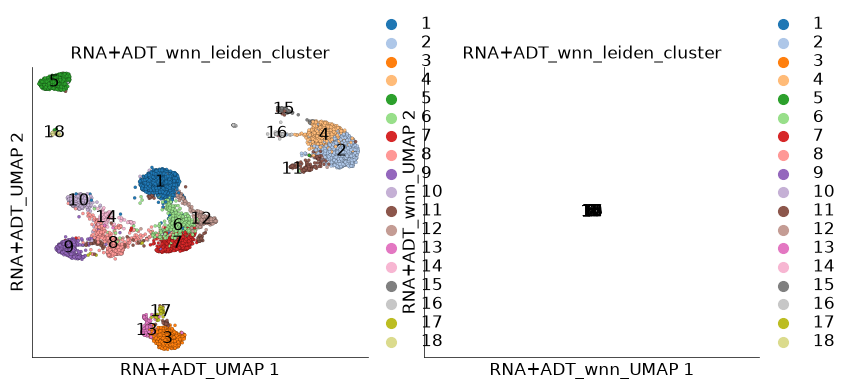

time: 1.04 s (started: 2026-06-29 18:30:06 +02:00)


In [33]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP", "RNA+ADT_wnn_UMAP"],
    color_by="RNA+ADT_wnn_leiden_cluster",
    cmap="tab20",
    point_size=5,
    width=4,
    height=4,
    n_columns=2,
)